## 📌 Loan Approval Prediction using Machine Learning

In [444]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [445]:
df = pd.read_csv(r"/content/loan_approval_dataset.csv")

In [446]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## Section 1: Data Understanding

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [448]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [449]:
# Change the values of all numeric columns of the dataframe upto 2 point decimal.

pd.set_option('display.float_format', '{:.2f}'.format)

In [450]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [451]:
# How many loan applications are there in this dataset?

df['loan_id'].count()

np.int64(4269)

In [452]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [453]:
# Strips the white space from both sides


df.columns = df.columns.str.strip()

In [454]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [455]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [456]:
df['education'] = df['education'].str.strip()

df['self_employed'] = df['self_employed'].str.strip()

df['loan_status'] = df['loan_status'].str.strip()

In [457]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [458]:
# What percentage of applicants get loan approved vs rejected?

df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [459]:
df['loan_status'].value_counts(normalize = True) * 100

,proportion
loan_status,
Approved,62.22
Rejected,37.78


In [460]:
# Are there missing values in the dataset? Which columns are most affected?

df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [461]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [462]:
# Change datatype of 'loan_id' column

df['loan_id'] = df['loan_id'].astype(str)

In [463]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


In [464]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


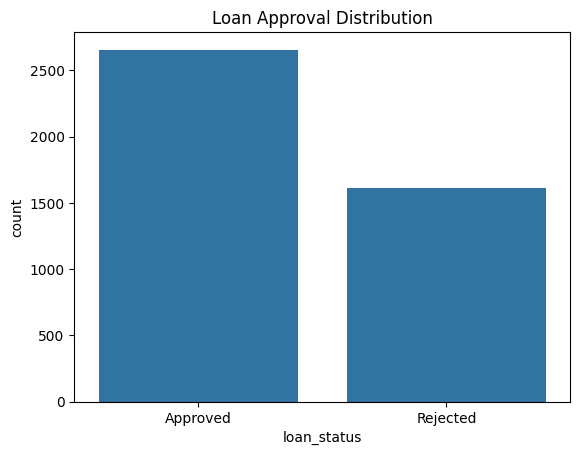

In [465]:
# Is the dataset balanced or imbalanced for loan approval?

sns.countplot(x = 'loan_status', data = df)
plt.title("Loan Approval Distribution")

plt.show()

## Section 2: Exploratory Data Analysis (EDA)

1. Does Employment Type affect loan approval?

In [466]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [467]:
df['self_employed'].value_counts()

,count
self_employed,
Yes,2150
No,2119


In [468]:
emp_status = df.groupby(['self_employed', 'loan_status'])['loan_status'].count().unstack()

emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [469]:
emp_status['Total'] = emp_status['Approved'] + emp_status['Rejected']

In [470]:
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


In [471]:
emp_status['Approval_%'] = emp_status['Approved'] / emp_status['Total'] * 100

In [472]:
emp_status

loan_status,Approved,Rejected,Total,Approval_%
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


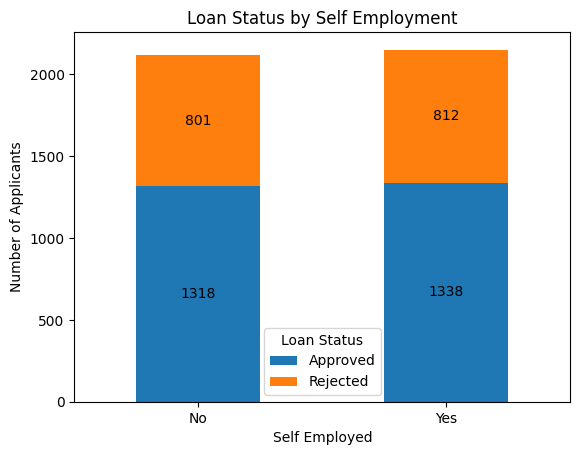

'This stacked bar chart clearly shows that approval rates are almost identical for self-employed and \nnon self-employed applicants, meaning employment type does not strongly influence approval.'

In [473]:
ax = emp_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax.containers:
    ax.bar_label(container, label_type = 'center')

plt.show()

"""This stacked bar chart clearly shows that approval rates are almost identical for self-employed and
non self-employed applicants, meaning employment type does not strongly influence approval."""

2. Do graduates get higher approval rates than non-graduates?

In [474]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [475]:
df['education'].value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


In [476]:
education_status = df.groupby(['education', 'loan_status'])['loan_status'].count().unstack()

education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [477]:
education_status['Total'] = education_status['Approved'] + education_status['Rejected']

In [478]:
education_status

loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125


In [479]:
education_status['Approval_%'] = education_status['Approved'] / education_status['Total'] * 100

In [480]:
education_status

loan_status,Approved,Rejected,Total,Approval_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


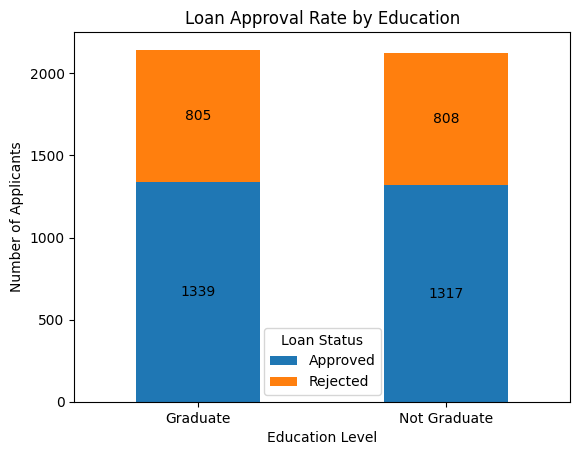

'This stacked bar chart clearly shows that approval rates are almost identical for graduate and \nnon-graduate applicants, meaning education does not strongly influence approval.'

In [481]:
# Plot stacked bar chart

ax1 = education_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Approval Rate by Education")
plt.ylabel("Number of Applicants")
plt.xlabel("Education Level")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax1.containers:
    ax1.bar_label(container, label_type = 'center')


plt.show()

"""This stacked bar chart clearly shows that approval rates are almost identical for graduate and
non-graduate applicants, meaning education does not strongly influence approval."""


3. Does having more dependents reduce approval chances?

In [482]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [483]:
df['no_of_dependents'].value_counts()

,count
no_of_dependents,
4,752
3,727
0,712
2,708
1,697
5,673


In [484]:
dep_status = df.groupby(['no_of_dependents', 'loan_status'])['loan_status'].count().unstack()

dep_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [485]:
dep_status['Total'] = dep_status['Approved'] + dep_status['Rejected']

In [486]:
dep_status

loan_status,Approved,Rejected,Total
no_of_dependents,,,
0,457,255,712
1,430,267,697
2,441,267,708
3,457,270,727
4,465,287,752
5,406,267,673


In [487]:
dep_status['Approval_%'] = dep_status['Approved'] / dep_status['Total'] * 100

In [488]:
dep_status

loan_status,Approved,Rejected,Total,Approval_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


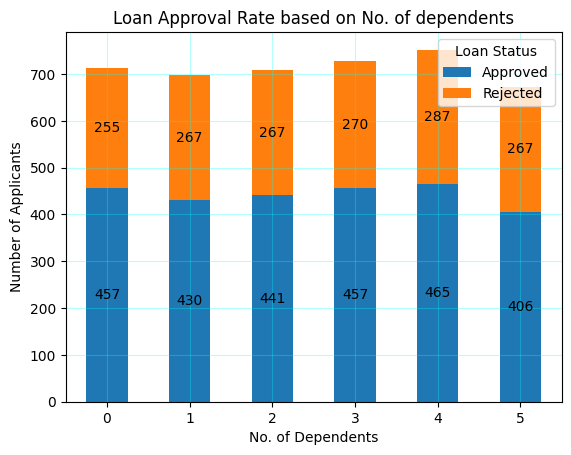

'"The approval rate generally decreases as the number of dependents increases, \nindicating that higher financial responsibility reduces the likelihood of loan approval.'

In [489]:
ax2 = dep_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Approval Rate based on No. of dependents")
plt.ylabel("Number of Applicants")
plt.xlabel("No. of Dependents")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.grid(True, color = 'cyan', alpha = 0.3)


for container in ax2.containers:
    ax2.bar_label(container, label_type = 'center')

plt.show()

""""The approval rate generally decreases as the number of dependents increases,
indicating that higher financial responsibility reduces the likelihood of loan approval."""

4. What is the relationship between applicant income and loan approval?

In [490]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [491]:
df['income_annum'].describe()

,income_annum
count,4269.00
mean,5059123.92
std,2806839.83
min,200000.00
25%,2700000.00
50%,5100000.00
75%,7500000.00
max,9900000.00


In [492]:
x = df.groupby(by = ['loan_status']).mean(numeric_only = True)['income_annum']

x

,income_annum
loan_status,
Approved,5025903.61
Rejected,5113825.17


In [493]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

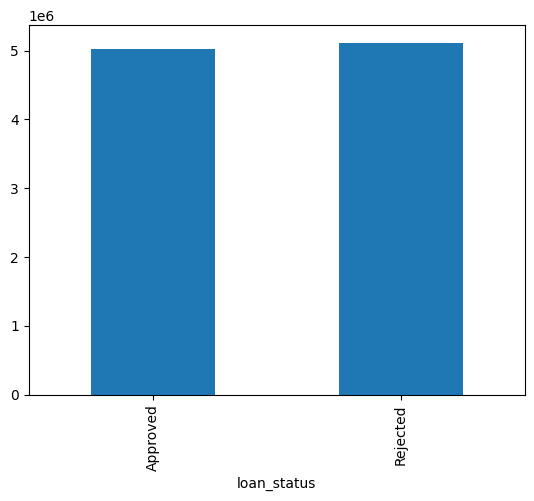

In [494]:
x.plot( kind = 'bar')

5. How does loan amount vary between approved and rejected loans?

In [495]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [496]:
df['loan_amount'].describe()

,loan_amount
count,4269.00
mean,15133450.46
std,9043362.98
min,300000.00
25%,7700000.00
50%,14500000.00
75%,21500000.00
max,39500000.00


In [497]:
df.groupby('loan_status').mean(numeric_only = True)['loan_amount']

,loan_amount
loan_status,
Approved,15247251.51
Rejected,14946063.24


In [498]:
approved_amount = df[df['loan_status'] == 'Approved']['loan_amount']

approved_amount

,loan_amount
0,29900000
6,33000000
8,2200000
10,11200000
13,31500000
...,...
4261,7500000
4263,12700000
4265,11300000
4267,12800000


In [499]:
rejected_amount = df[df['loan_status'] == 'Rejected']['loan_amount']

rejected_amount

,loan_amount
1,12200000
2,29700000
3,30700000
4,24200000
5,13500000
...,...
4258,22600000
4259,11500000
4262,3000000
4264,2300000


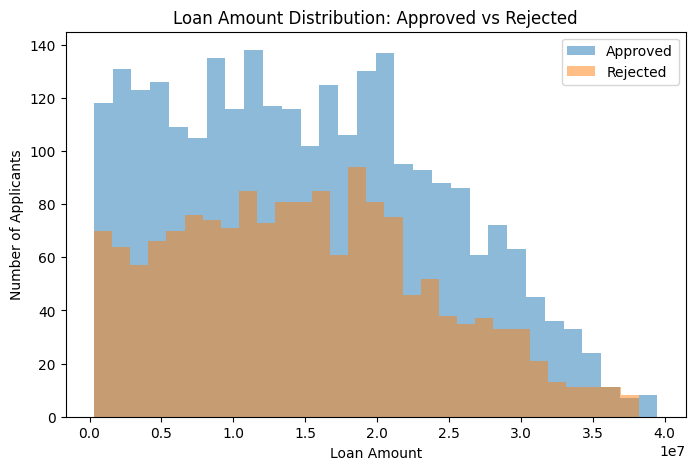

In [500]:
# Plot histogram

plt.figure(figsize = (8,5))

plt.hist( approved_amount, bins = 30, alpha = 0.5, label = 'Approved')
plt.hist( rejected_amount, bins = 30, alpha = 0.5, label = 'Rejected')

plt.title("Loan Amount Distribution: Approved vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

# Approved loans are more concentrated around moderate loan amounts

6. Does Cibil Score strongly influence loan approval?

In [501]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [502]:
df['cibil_score'].describe()

,cibil_score
count,4269.00
mean,599.94
std,172.43
min,300.00
25%,453.00
50%,600.00
75%,748.00
max,900.00


In [503]:
df.groupby('loan_status')['cibil_score'].mean()

,cibil_score
loan_status,
Approved,703.46
Rejected,429.47


In [504]:
# Separate loan amounts

approved_cibil = df[df['loan_status'] == 'Approved']['cibil_score']
rejected_cibil = df[df['loan_status'] == 'Rejected']['cibil_score']

In [505]:
approved_cibil

,cibil_score
0,778
6,678
8,782
10,547
13,679
...,...
4261,881
4263,865
4265,559
4267,780


In [506]:
rejected_cibil

,cibil_score
1,417
2,506
3,467
4,382
5,319
...,...
4258,346
4259,509
4262,540
4264,317


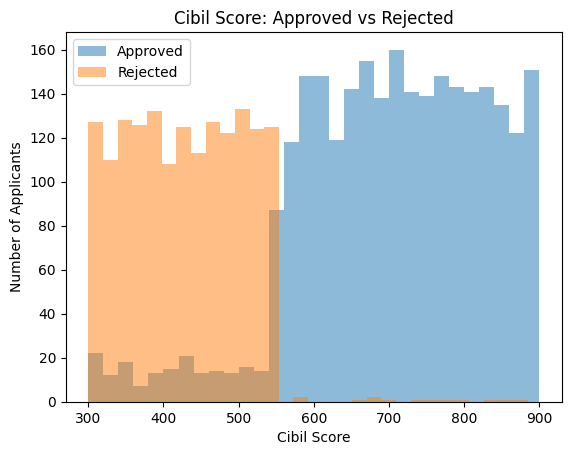

'The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges, \nwhile rejected loans are more common at lower CIBIL scores.\nThis confirms that credit score is a strong factor influencing loan approval.'

In [507]:
plt.hist(approved_cibil, bins = 30, alpha = 0.5, label = 'Approved')
plt.hist(rejected_cibil, bins = 30, alpha = 0.5, label = 'Rejected')

plt.title("Cibil Score: Approved vs Rejected")
plt.xlabel("Cibil Score")
plt.ylabel("Number of Applicants")
plt.legend()


plt.show()

'''The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges,
while rejected loans are more common at lower CIBIL scores.
This confirms that credit score is a strong factor influencing loan approval.'''


## Section 3: Data Visualization

A. Compare Applicant Income vs Loan Amount (scatter plot)

In [508]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


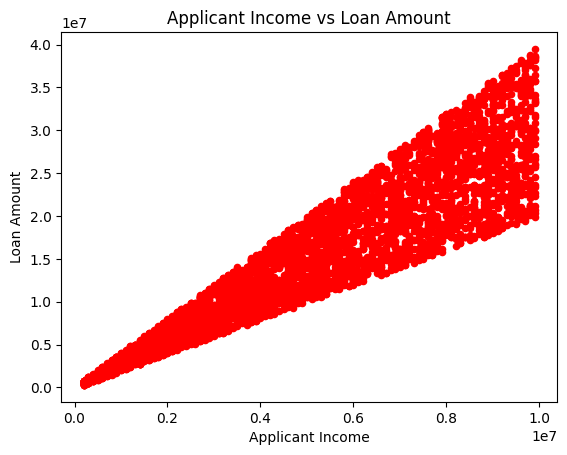

In [509]:
df.plot( x = 'income_annum', y = 'loan_amount', kind = 'scatter', color = 'red')
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")



plt.show()

B. Show correlation heatmap of numerical features

In [510]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


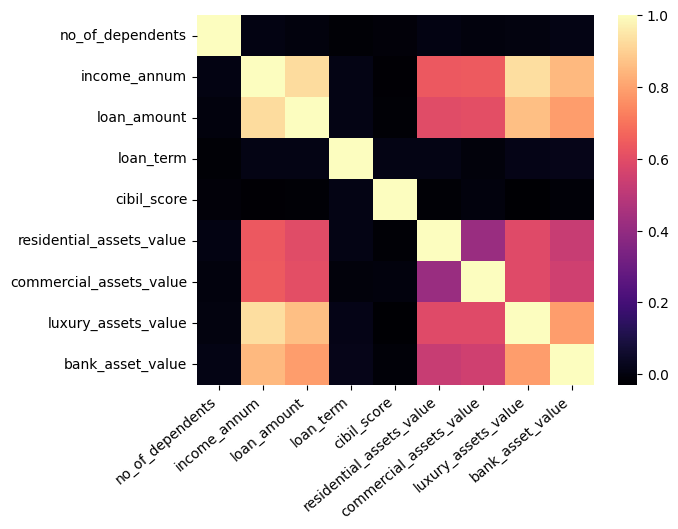

In [511]:
sns.heatmap( df.corr(numeric_only = True), cmap = 'magma' )

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [512]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.9274699109871488)

In [513]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522586)

## Section 4: Data Cleaning & Feature Engineering

Detect Outliers

In [514]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


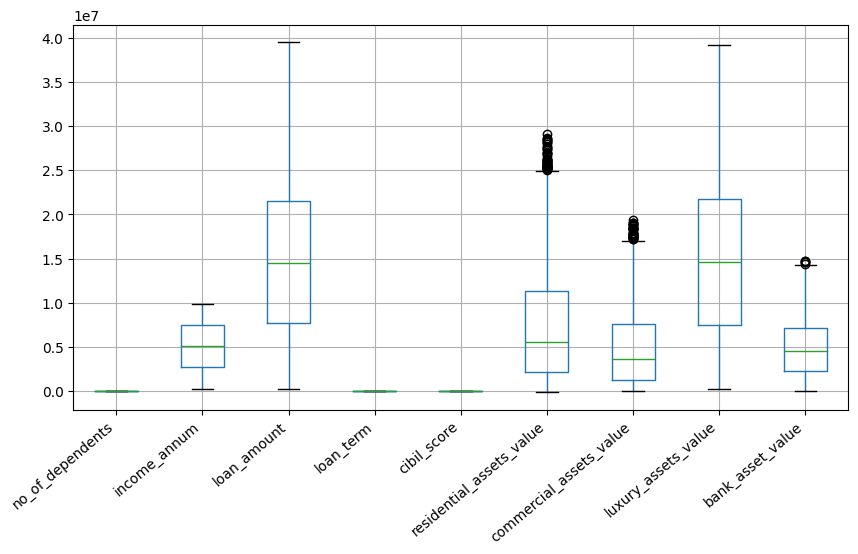

In [515]:
plt.figure(figsize = (10,5))

df.boxplot()

plt.xticks(rotation = 40, ha = 'right')

plt.show()

Remove Outliers

In [516]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [517]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [518]:
# Calculate Quartile

R_Q1 = df['residential_assets_value'].quantile(0.25)
R_Q3 = df['residential_assets_value'].quantile(0.75)

# Calculate IQR
IQR = R_Q3 - R_Q1

In [519]:
IQR

np.float64(9100000.0)

In [520]:
lower_limit = R_Q1 - 1.5 * IQR

upper_limit = R_Q3 + 1.5 * IQR

In [521]:
df = df[(df['residential_assets_value'] >= lower_limit) & (df['residential_assets_value'] <= upper_limit)]

In [522]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


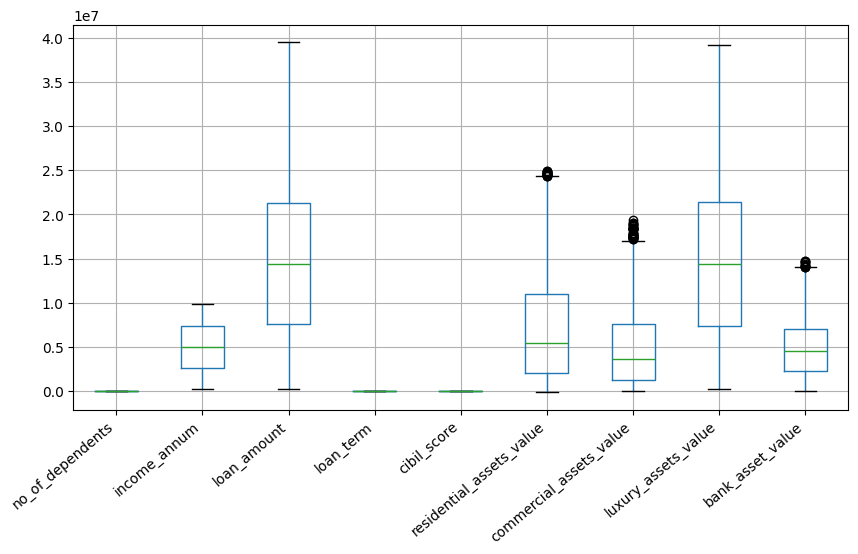

In [523]:
plt.figure(figsize = (10,5))

df.boxplot()

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [524]:
# Calculare Quartile

C_Q1 = df['commercial_assets_value'].quantile(0.25)

C_Q3 = df['commercial_assets_value'].quantile(0.75)


# Calculate IQR

C_IQR = C_Q3 - C_Q1

lower_limit = C_Q1 - 1.5 * C_IQR
upper_limit = C_Q3 + 1.5 * C_IQR

# Lower outlier limit

df = df[(df['commercial_assets_value'] >= lower_limit) & (df['commercial_assets_value'] <= upper_limit)]

In [525]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


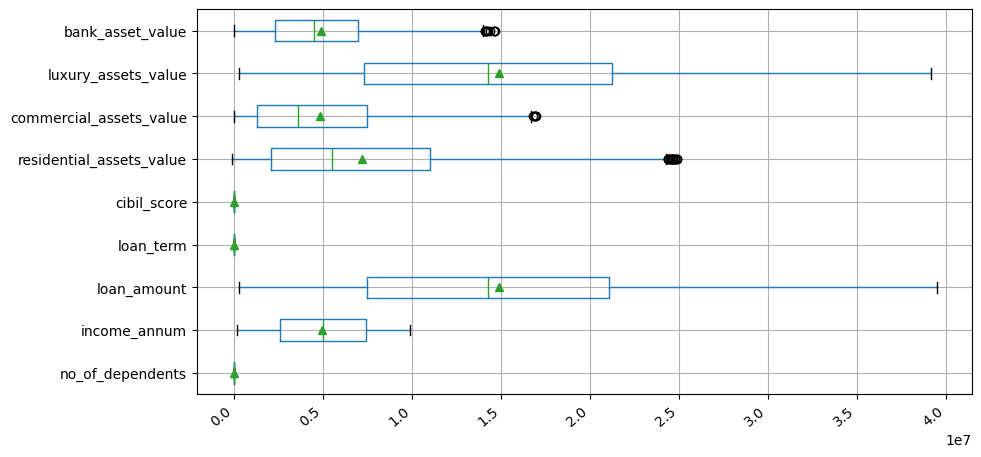

In [526]:
plt.figure(figsize = (10,5))

df.boxplot( showmeans = True , vert = False)

plt.xticks(rotation = 40, ha = 'right')

plt.show()

Which features should be dropped (like Loan_ID)?

In [527]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [528]:
df = df.drop('loan_id', axis = 1)

In [529]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


Convert categorical variables into numeric using Maping, Label Encoding & One Hot Encoding?

Mapping

In [530]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [531]:
df['loan_status'] = df['loan_status'].map({'Approved' : 1, 'Rejected' : 0})

In [532]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


Label Encoding

In [533]:
# Encode Binary Column

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['self_employed'] = le.fit_transform(df['self_employed'])

In [534]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


One-hot Encoding

In [535]:
df = pd.get_dummies(df, columns = ['education'])

In [536]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


# Model Building

In [537]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = df.drop('loan_status', axis = 1)
y = df['loan_status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

models = {"Logistic Regression" : LogisticRegression(max_iter = 1000),
          "Decision Tree" : DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier()
         }
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy", accuracy_score(y_test, preds) )

Logistic Regression Accuracy 0.7968936678614098
Decision Tree Accuracy 0.972520908004779
Random Forest Accuracy 0.974910394265233


In [538]:
#  Step 1: Split Features and Target

X = df.drop('loan_status', axis = 1)
y = df['loan_status']

In [539]:
#  Step 2: Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [540]:
#  Step 3: Build Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators = 200, max_depth = 10, random_state = 39 )

In [541]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=39)

In [542]:
#  Step 4: Make Predictions

y_pred = rf_model.predict(X_test)

In [543]:
#  Step 5: Evaluate the Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred) * 100, "%")
print("Classification Report :", classification_report(y_test, y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test, y_pred))

Accuracy : 97.0131421744325 %
Classification Report :               precision    recall  f1-score   support

           0       0.97      0.95      0.96       316
           1       0.97      0.98      0.98       521

    accuracy                           0.97       837
   macro avg       0.97      0.97      0.97       837
weighted avg       0.97      0.97      0.97       837

Confusion Matrix : [[300  16]
 [  9 512]]


In [544]:
#  Step 6: Feature Importance

feature_importance = pd.Series( rf_model.feature_importances_, index = X.columns ).sort_values(ascending = False)

feature_importance

,0
cibil_score,0.83
loan_term,0.06
loan_amount,0.03
residential_assets_value,0.02
income_annum,0.02
commercial_assets_value,0.02
luxury_assets_value,0.02
bank_asset_value,0.01
no_of_dependents,0.01
self_employed,0.00


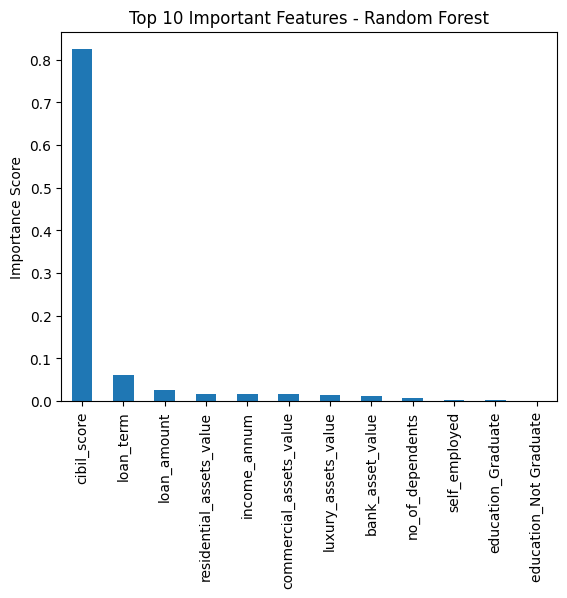

In [545]:
import matplotlib.pyplot as plt

feature_importance.plot(kind = 'bar')
plt.title("Top 10 Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.show()


## Model Prediction

In [546]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


In [547]:
# For a new customer

new_applicant = {
    'no_of_dependents': 4,
    'self_employed': 1,
    'income_annum': 600000,
    'loan_amount': 250000,
    'loan_term': 36,
    'cibil_score': 900,
    'residential_assets_value': 30,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 6000,
    'education_Graduate': 1,
    'education_Not Graduate':1,
}

new_df = pd.DataFrame([new_applicant])

In [548]:
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,4,1,600000,250000,36,900,30,0,0,6000,1,1


In [549]:
prediction = rf_model.predict(new_df)

In [550]:
prediction

array([1])

## Save Model

In [551]:
import joblib

joblib.dump(rf_model, 'loan_approval_prediction.pkl')

['loan_approval_prediction.pkl']

In [552]:
# Load and Use :

loaded_model = joblib.load('loan_approval_prediction.pkl')

In [553]:
loaded_model

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=39)